In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.linear_model import LogisticRegression

# from sklearn.ensemble import IsolationForest
from feature_engine.outliers import Winsorizer

from sklearn.model_selection import train_test_split, GridSearchCV

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline


from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.ensemble import StackingClassifier

from sklearn.metrics import classification_report,roc_auc_score,RocCurveDisplay


In [3]:
import sys
print(sys.executable)

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\python.exe


In [4]:
# pd.read_csv("/kaggle/input/datasets/maazk10/e-commerce-churn-dataset/data_ecommerce_customer_churn.csv")

pd.read_csv(r"C:\Users\ASUS\Documents\VSCode\ML\ML_projects\Amazon MLSS\Churn Prediction\data_ecommerce_customer_churn.csv")


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


In [5]:
# df = pd.read_csv(r"/kaggle/input/datasets/maazk10/e-commerce-churn-dataset/data_ecommerce_customer_churn.csv")

df = pd.read_csv(r"C:\Users\ASUS\Documents\VSCode\ML\ML_projects\Amazon MLSS\Churn Prediction\data_ecommerce_customer_churn.csv")


print(df.shape)

print(df.isna().sum())

(3941, 11)
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64


In [6]:
df['PreferedOrderCat'].unique()

array(['Laptop & Accessory', 'Mobile', 'Fashion', 'Others',
       'Mobile Phone', 'Grocery'], dtype=object)

In [7]:
df['MaritalStatus'].unique()

array(['Single', 'Married', 'Divorced'], dtype=object)

In [8]:
df.max()

Tenure                        61.0
WarehouseToHome              127.0
NumberOfDeviceRegistered         6
PreferedOrderCat            Others
SatisfactionScore                5
MaritalStatus               Single
NumberOfAddress                 22
Complain                         1
DaySinceLastOrder             46.0
CashbackAmount              324.99
Churn                            1
dtype: object

In [9]:
df.min()

Tenure                           0.0
WarehouseToHome                  5.0
NumberOfDeviceRegistered           1
PreferedOrderCat             Fashion
SatisfactionScore                  1
MaritalStatus               Divorced
NumberOfAddress                    1
Complain                           0
DaySinceLastOrder                0.0
CashbackAmount                   0.0
Churn                              0
dtype: object

### Splitting Dataset

In [15]:
X = df.iloc[:,:-1] #.to_numpy()
y = df.iloc[:,-1] #.to_numpy().reshape(-1,1)

print(X.shape)
print(X)
print(y.shape)
print(y)


(3941, 10)
      Tenure  WarehouseToHome  NumberOfDeviceRegistered    PreferedOrderCat  \
0       15.0             29.0                         4  Laptop & Accessory   
1        7.0             25.0                         4              Mobile   
2       27.0             13.0                         3  Laptop & Accessory   
3       20.0             25.0                         4             Fashion   
4       30.0             15.0                         4              Others   
...      ...              ...                       ...                 ...   
3936    28.0              9.0                         5             Fashion   
3937     8.0              7.0                         2        Mobile Phone   
3938    30.0              6.0                         5  Laptop & Accessory   
3939     6.0              NaN                         4              Mobile   
3940     2.0              7.0                         3  Laptop & Accessory   

      SatisfactionScore MaritalStatus  N

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y , random_state=67)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)


(3152, 10)
(3152,)
(789, 10)
(789,)


### Making Full Pipeline (Transformation pipeline + Ensemble Model )

```mermaid
flowchart LR
    A[" "] --> B[OneHotEncoder]
    subgraph Tranformation [Transformation pipeline]
        B --> C["Outlier Handling \n ( Winsorization )"]
        C --> D[KNN Imputing]
        D --> D1[Scaling]
        D1 --> E[SMOTE]
    end    
    E --> E1(["Ensemble Model \n (training & evalution)"])
    E1 --> F[" "]

   style A fill:none,stroke:none,color:none;
   style F fill:none,stroke:none,color:none ;
```

<br></br>
<br></br>


**Note :** Test set won't undergo SMOTE, even if we pass it in imblearn pipeline. This is the advantage of using imblearn's pipeline over scikit-learn's. 

In [28]:
OHE_and_winsorize = ColumnTransformer(
    transformers=[
        ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),['PreferedOrderCat','MaritalStatus']),
        ('Winsorizer',Winsorizer(capping_method='iqr',tail='both',fold=1.5,missing_values='ignore'),['Tenure','WarehouseToHome','NumberOfDeviceRegistered','SatisfactionScore','NumberOfAddress','DaySinceLastOrder','CashbackAmount']) 
    ],
    remainder='passthrough'
)

base_models = [
    ('knn',KNeighborsClassifier(n_neighbors=3)),
    ('svm',SVC(probability=True,class_weight='balanced', random_state=67)),
    ('xgboost',XGBClassifier(use_label_encoder=False,eval_metric='logloss',random_state=67)),
    ('random_forest',RandomForestClassifier(class_weight='balanced',random_state=67)),
]

ensemble_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5
)

''' Final Pipeline '''

pipeline = Pipeline(steps=[
    ('onehotencode then winsorize',OHE_and_winsorize),
    ('imputer',KNNImputer(n_neighbors=2)),
    ('scaler',StandardScaler()),
    ('smote',SMOTE(random_state=67,k_neighbors=1)),
    ('ensemble',ensemble_model)
])


### Hyperparameters Fine-Tuning & Training

In [33]:
param_grid= {
    'smote__sampling_strategy' : [0.8,1.0],
    'smote__k_neighbors' : [3,5],
    'ensemble__random_forest__n_estimators' : [100,200],
    'ensemble__random_forest__max_depth' : [None,10,20],
    'ensemble__xgboost__scale_pos_weight' : [3,5,7],
    'ensemble__final_estimator__C' : [0.1,1,10]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:18:24] WARNING: C:\actions-r

,estimator,Pipeline(step...gression()))])
,param_grid,"{'ensemble__final_estimator__C': [0.1, 1, ...], 'ensemble__random_forest__max_depth': [None, 10, ...], 'ensemble__random_forest__n_estimators': [100, 200], 'ensemble__xgboost__scale_pos_weight': [3, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe', ...), ('Winsorizer', ...)]"


### Training

In [ ]:
#pipeline.fit(X_train,y_train)

### Testing & Evalution

In [ ]:
best_pipeline = grid_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       654
           1       0.89      0.86      0.88       135

    accuracy                           0.96       789
   macro avg       0.93      0.92      0.93       789
weighted avg       0.96      0.96      0.96       789



0.9769622833843018


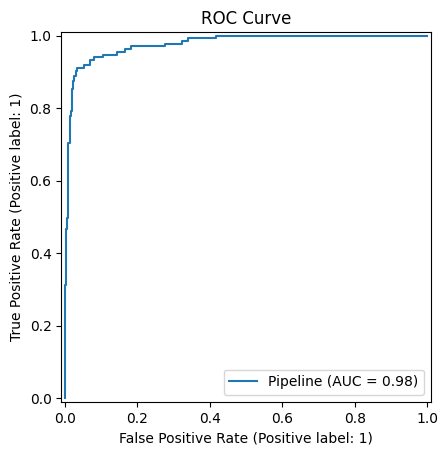

In [43]:
import matplotlib.pyplot as plt

y_pred_proba = best_pipeline.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test,y_pred_proba)

print(auc_score)

RocCurveDisplay.from_estimator(best_pipeline,X_test,y_test)
plt.title("ROC Curve")
plt.show()

### Saving the best pipeline

In [35]:
import joblib

joblib.dump(best_pipeline,'transformation_pipeline_and_stacking_ensemble.joblib')

['transformation_pipeline_and_stacking_ensemble.joblib']